# Predict medical insurance costs

**Outline**
1. Setup and data
2. Feature normalisation
3. Linear regression with one feature
4. Multiple linear regression
5. DNN with one feature
6. DNN with multiple features
7. Performance comparison
8. Predictions from the best model
9. Extension: advanced techniques
10. Conclusion

## 1. Setup

In [1]:
%pip install -q seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.set_printoptions(precision=3, suppress=True)

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.20.0


In [4]:
DATA_PATH = "/kaggle/input/datasets/harishkumardatalab/medical-insurance-price-prediction/Medical_insurance.csv"   
TARGET = "charges"            
SINGLE_FEATURE = "age"        
EPOCHS = 100
SEED = 42

tf.keras.utils.set_random_seed(SEED)

## 2. The dataset

### Get the data

In [5]:
raw_dataset = pd.read_csv(DATA_PATH)
dataset = raw_dataset.copy()
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


### Clean the data

In [7]:
print(dataset.isna().sum())
print("Duplicate rows:", dataset.duplicated().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicate rows: 1435


In [8]:
dataset = dataset.dropna()
dataset = dataset.drop_duplicates()

In [9]:
cat_cols = dataset.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)

dataset = pd.get_dummies(dataset, columns=cat_cols, drop_first=True, dtype=float)
dataset.head()

Categorical columns: ['sex', 'smoker', 'region']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1.0,0.0,1.0,0.0,0.0


### Split the data into training and test sets

In [10]:
train_dataset = dataset.sample(frac=0.8, random_state=SEED)
test_dataset = dataset.drop(train_dataset.index)
print(len(train_dataset), len(test_dataset))

1070 267


### Inspect the data

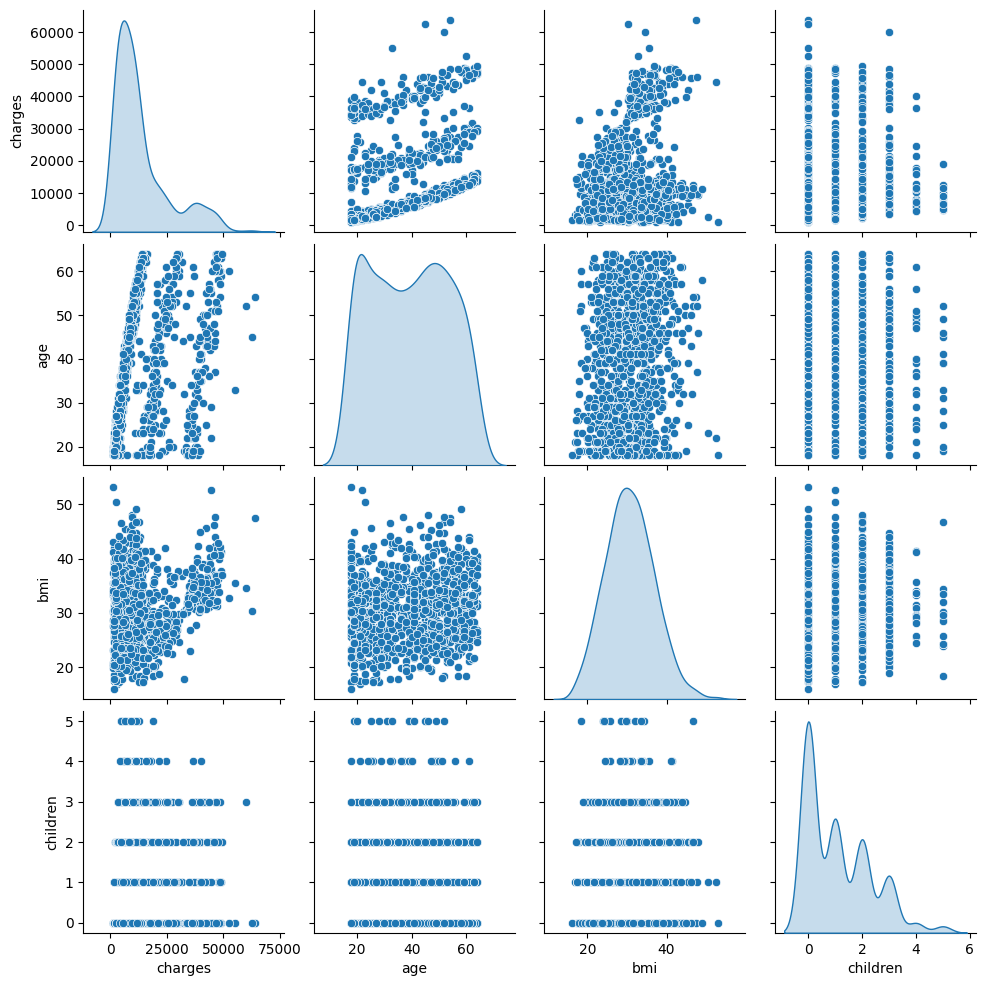

In [11]:
sns.pairplot(train_dataset[[TARGET, "age", "bmi", "children"]], diag_kind="kde")

In [12]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1070.0,39.261682,13.997752,18.0000,27.00000,39.000000,51.0000,64.00000
bmi,1070.0,30.713720,6.115022,15.9600,26.41000,30.495000,34.7525,53.13000
children,1070.0,1.101869,1.208752,0.0000,0.00000,1.000000,2.0000,5.00000
charges,1070.0,13353.159837,12154.199524,1121.8739,4755.80985,9447.316375,17084.2207,63770.42801
sex_male,1070.0,0.509346,0.500146,0.0000,0.00000,1.000000,1.0000,1.00000
smoker_yes,1070.0,0.205607,0.404334,0.0000,0.00000,0.000000,0.0000,1.00000
region_northwest,1070.0,0.242056,0.428528,0.0000,0.00000,0.000000,0.0000,1.00000
region_southeast,1070.0,0.272897,0.445657,0.0000,0.00000,0.000000,1.0000,1.00000
region_southwest,1070.0,0.251402,0.434022,0.0000,0.00000,0.000000,1.0000,1.00000


### Split features from labels
The label is scaled to **thousands of dollars**. This keeps the loss values small and training stable. All errors below are in thousands of dollars.

In [13]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop(TARGET) / 1000.0
test_labels = test_features.pop(TARGET) / 1000.0

feature_names = train_features.columns.tolist()
print(feature_names)

['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


## 3. Normalization

Features have very different ranges. Normalising them makes training more stable. The `Normalization` layer learns the mean and variance from the training data with `adapt`.

In [14]:
train_features.describe().transpose()[["mean", "std"]]

,mean,std
age,39.261682,13.997752
bmi,30.713720,6.115022
children,1.101869,1.208752
sex_male,0.509346,0.500146
smoker_yes,0.205607,0.404334
region_northwest,0.242056,0.428528
region_southeast,0.272897,0.445657
region_southwest,0.251402,0.434022


In [15]:
X_train = train_features.to_numpy(dtype="float32")
X_test = test_features.to_numpy(dtype="float32")

normalizer = layers.Normalization(axis=-1)
normalizer.adapt(X_train)

print(normalizer.mean.numpy())

[[39.262 30.714  1.102  0.509  0.206  0.242  0.273  0.251]]


I0000 00:00:1791365627.211803     139 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791365627.215442     139 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
first = X_train[:1]

print("First example:", first)
print()
print("Normalized:", normalizer(first).numpy())

First example: [[49.    22.515  0.     1.     0.     0.     0.     0.   ]]

Normalized: [[ 0.696 -1.341 -0.912  0.981 -0.509 -0.565 -0.613 -0.58 ]]


## 4. Linear regression with one feature

In [17]:
X_train_one = train_features[[SINGLE_FEATURE]].to_numpy(dtype="float32")
X_test_one = test_features[[SINGLE_FEATURE]].to_numpy(dtype="float32")

one_normalizer = layers.Normalization(axis=None)
one_normalizer.adapt(X_train_one)

In [18]:
one_feature_model = keras.Sequential([
    keras.Input(shape=(1,)),
    one_normalizer,
    layers.Dense(units=1),
])

one_feature_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [19]:
one_feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_absolute_error",
)

In [20]:
history = one_feature_model.fit(
    X_train_one,
    train_labels,
    epochs=EPOCHS,
    verbose=0,
    validation_split=0.2,
)

I0000 00:00:1791365630.672972     221 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


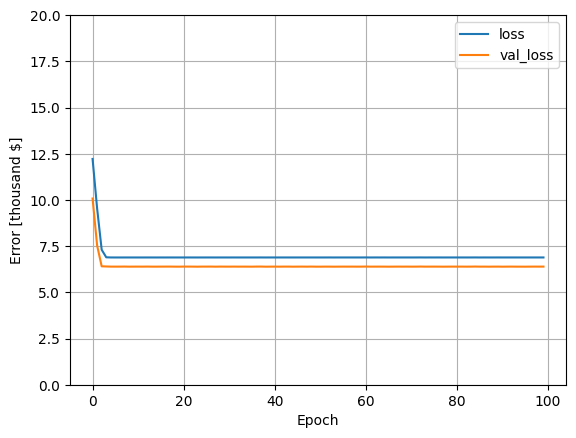

In [21]:
def plot_loss(history, ylim=None):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    if ylim:
        plt.ylim(ylim)
    plt.xlabel("Epoch")
    plt.ylabel("Error [thousand $]")
    plt.legend()
    plt.grid(True)

plot_loss(history, ylim=[0, 20])

In [22]:
# Registry used later for the comparison.
# Each entry: name -> (model, test inputs)
registry = {}
registry["linear_one_feature"] = (one_feature_model, X_test_one)

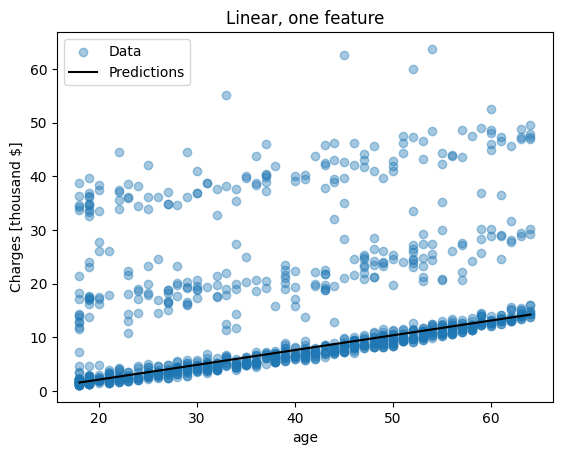

In [23]:
def plot_single_feature(model, title):
    x = np.linspace(X_train_one.min(), X_train_one.max(), 200).reshape(-1, 1)
    y = model.predict(x, verbose=0)
    plt.scatter(X_train_one, train_labels, label="Data", alpha=0.4)
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel(SINGLE_FEATURE)
    plt.ylabel("Charges [thousand $]")
    plt.title(title)
    plt.legend()

plot_single_feature(one_feature_model, "Linear, one feature")

## 5. Multiple linear regression

In [24]:
linear_model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    normalizer,
    layers.Dense(units=1),
])

linear_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_absolute_error",
)

In [25]:
history = linear_model.fit(
    X_train,
    train_labels,
    epochs=EPOCHS,
    verbose=0,
    validation_split=0.2,
)

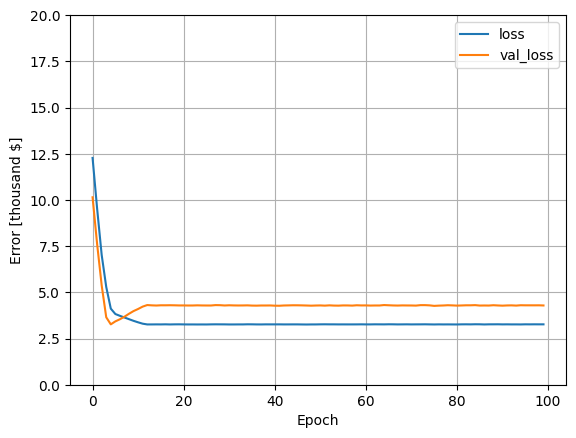

In [26]:
plot_loss(history, ylim=[0, 20])

In [27]:
registry["linear_multi_feature"] = (linear_model, X_test)

## 6. Regression with a deep neural network (DNN)

The DNN has these layers:
- The normalization layer
- Two hidden `Dense` layers with ReLU
- One linear output layer

In [28]:
def build_and_compile_model(norm, n_inputs):
    model = keras.Sequential([
        keras.Input(shape=(n_inputs,)),
        norm,
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ])

    model.compile(
        loss="mean_absolute_error",
        optimizer=keras.optimizers.Adam(0.001),
    )
    return model

### DNN with one feature

In [29]:
dnn_one_model = build_and_compile_model(one_normalizer, n_inputs=1)
dnn_one_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 3 (16.00 B)

In [30]:
history = dnn_one_model.fit(
    X_train_one,
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=EPOCHS,
)

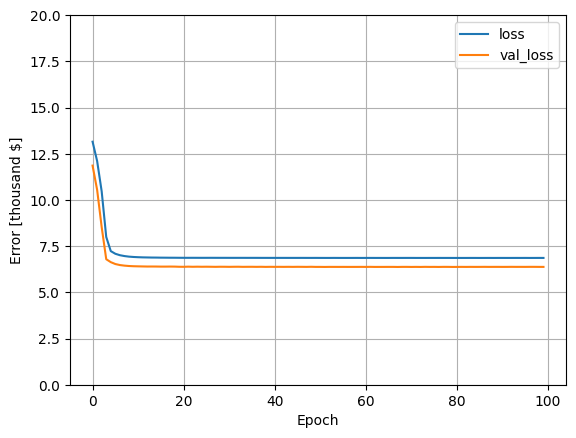

In [31]:
plot_loss(history, ylim=[0, 20])

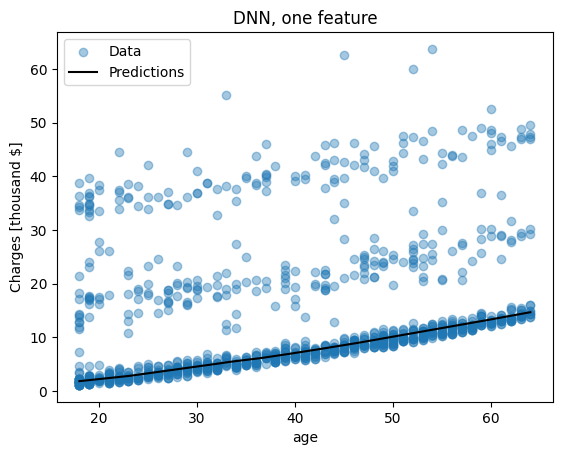

In [32]:
plot_single_feature(dnn_one_model, "DNN, one feature")

In [33]:
registry["dnn_one_feature"] = (dnn_one_model, X_test_one)

### DNN with multiple features

In [34]:
dnn_model = build_and_compile_model(normalizer, n_inputs=X_train.shape[1])
dnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,818 (18.82 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 17 (72.00 B)

In [35]:
history = dnn_model.fit(
    X_train,
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=EPOCHS,
)

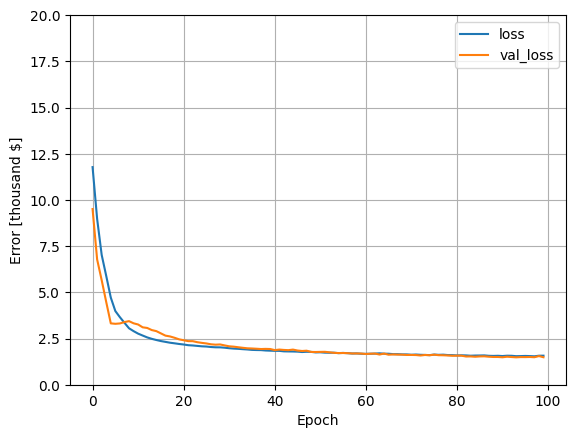

In [36]:
plot_loss(history, ylim=[0, 20])

In [37]:
registry["dnn_multi_feature"] = (dnn_model, X_test)

## 7. Performance comparison

Each model is scored on the test set with MAE, RMSE and R². Errors are in thousands of dollars.

In [38]:
def get_metrics(model, X, y):
    pred = model.predict(X, verbose=0).flatten()
    return {
        "MAE [thousand $]": mean_absolute_error(y, pred),
        "RMSE [thousand $]": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
    }

results = {name: get_metrics(m, X, test_labels) for name, (m, X) in registry.items()}
results_df = pd.DataFrame(results).T.sort_values("MAE [thousand $]")
results_df

,MAE [thousand $],RMSE [thousand $],R2
dnn_multi_feature,1.570323,4.529794,0.855796
linear_multi_feature,3.341831,6.947544,0.660779
dnn_one_feature,6.413130,12.858421,-0.161971
linear_one_feature,6.441299,12.764525,-0.145063


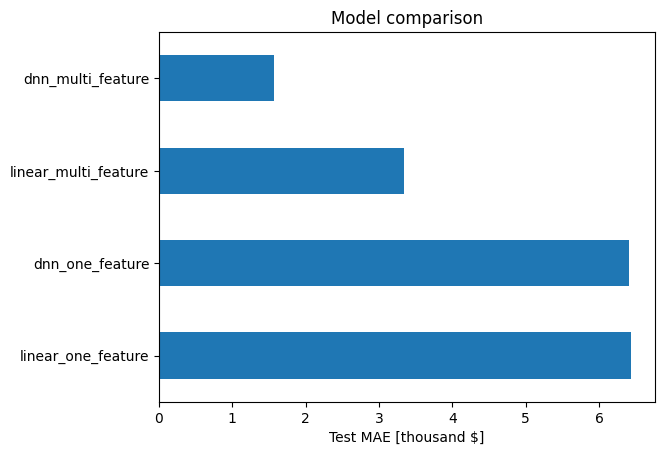

In [39]:
results_df["MAE [thousand $]"].plot(kind="barh")
plt.xlabel("Test MAE [thousand $]")
plt.title("Model comparison")
plt.gca().invert_yaxis()

## 8. Predictions from the best model

Best model: dnn_multi_feature


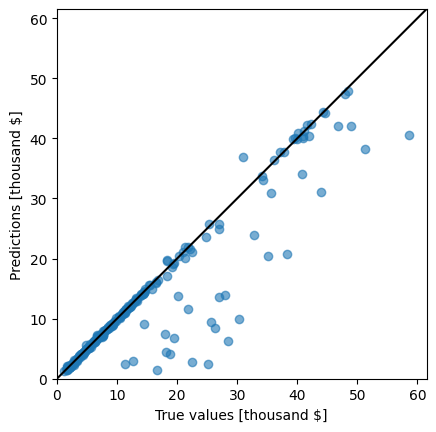

In [40]:
best_name = results_df.index[0]
best_model, best_X = registry[best_name]
print("Best model:", best_name)

test_predictions = best_model.predict(best_X, verbose=0).flatten()

a = plt.axes(aspect="equal")
plt.scatter(test_labels, test_predictions, alpha=0.6)
plt.xlabel("True values [thousand $]")
plt.ylabel("Predictions [thousand $]")
lims = [0, max(test_labels.max(), test_predictions.max()) * 1.05]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims, color="k")

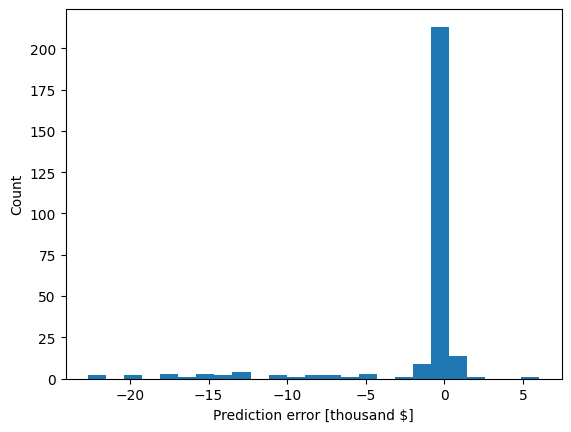

In [41]:
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel("Prediction error [thousand $]")
_ = plt.ylabel("Count")

Save the best model.

In [42]:
best_model.save("best_model.keras")

reloaded = keras.models.load_model("best_model.keras")
print(get_metrics(reloaded, best_X, test_labels))

{'MAE [thousand $]': 1.5703225820517845, 'RMSE [thousand $]': np.float64(4.529794268642461), 'R2': 0.8557960778608524}


## 9. Extension: advanced techniques

The models above use one train/test split and one fixed DNN design. This section goes further:

1. Feature engineering (interaction terms)
2. Ablation study (what helps?)
3. Log-transformed target
4. Regularisation (dropout, L2) and training callbacks (early stopping, learning-rate decay)
5. Hyperparameter tuning with random search
6. Final tuned DNN
7. Gradient boosting as a classic ML baseline
8. 5-fold cross-validation
9. Feature importance and error analysis
10. Final comparison of all models

**Rules used here**
- All new names start with `ext_`, so nothing above is overwritten.
- Tuning uses a validation split of the training data only.
- The test set is used once, for the final scores.

In [43]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import GradientBoostingRegressor

EXT_SEED = 42
EXT_EPOCHS = 300        # upper limit, early stopping ends training sooner
EXT_N_TRIALS = 12       # random search trials
EXT_N_FOLDS = 5         # cross-validation folds
EXT_SMOKER, EXT_BMI, EXT_AGE = "smoker_yes", "bmi", "age"   # column names after one-hot encoding

### 9.1 Feature engineering

Insurance cost often depends on combinations of features, such as smoker status and BMI. A linear model cannot find these on its own. Interaction and squared terms give it that information. Original columns come first, new columns are added at the end.

In [44]:
def ext_make_features(df):
    out = df.copy()
    out["smoker_x_bmi"] = out[EXT_SMOKER] * out[EXT_BMI]
    out["smoker_x_age"] = out[EXT_SMOKER] * out[EXT_AGE]
    out["smoker_x_obese"] = out[EXT_SMOKER] * (out[EXT_BMI] >= 30).astype(float)
    out["age_sq"] = out[EXT_AGE] ** 2
    out["bmi_sq"] = out[EXT_BMI] ** 2
    return out

ext_train_df = ext_make_features(train_features)
ext_test_df = ext_make_features(test_features)
ext_feature_names = ext_train_df.columns.tolist()
ext_n_base = len(feature_names)

ext_X_train = ext_train_df.to_numpy(dtype="float32")
ext_X_test = ext_test_df.to_numpy(dtype="float32")
ext_y_train = train_labels.to_numpy(dtype="float32")
ext_y_test = test_labels.to_numpy(dtype="float32")

print(ext_n_base, "->", len(ext_feature_names), "features")
print(ext_feature_names)

8 -> 13 features
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_x_bmi', 'smoker_x_age', 'smoker_x_obese', 'age_sq', 'bmi_sq']


### 9.2 Helper functions

- `ext_build_dnn`: builds a normalised DNN. `units=()` gives a linear model.
- `ext_fit`: trains with early stopping and learning-rate decay. It can train on `log1p(charges)`.
- `ext_predict`: predicts and converts back to thousand dollars.

In [45]:
def ext_build_dnn(X_adapt, units=(64, 64), dropout=0.0, l2=0.0, lr=1e-3, loss="mean_absolute_error"):
    ext_norm = layers.Normalization(axis=-1)
    ext_norm.adapt(X_adapt)
    reg = keras.regularizers.l2(l2) if l2 > 0 else None

    stack = [keras.Input(shape=(X_adapt.shape[1],)), ext_norm]
    for u in units:
        stack.append(layers.Dense(u, activation="relu", kernel_regularizer=reg))
        if dropout > 0:
            stack.append(layers.Dropout(dropout))
    stack.append(layers.Dense(1))

    model = keras.Sequential(stack)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss=loss)
    return model


def ext_callbacks(patience=25):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(patience // 3, 3), min_lr=1e-5),
    ]


def ext_fit(X, y, log_target=False, batch_size=32, epochs=EXT_EPOCHS, seed=EXT_SEED, **build_kwargs):
    tf.keras.utils.set_random_seed(seed)
    model = ext_build_dnn(X, **build_kwargs)
    target = np.log1p(y) if log_target else y
    hist = model.fit(
        X, target,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=ext_callbacks(),
    )
    return model, hist


def ext_predict(model, X, log_target=False):
    pred = model.predict(X, verbose=0).flatten()
    return np.expm1(pred) if log_target else pred


def ext_metrics(y_true, y_pred):
    return {
        "MAE [thousand $]": mean_absolute_error(y_true, y_pred),
        "RMSE [thousand $]": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def ext_plot_history(hist, title=""):
    plt.plot(hist.history["loss"], label="loss")
    plt.plot(hist.history["val_loss"], label="val_loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(True)

A configuration is a dictionary. Missing keys use the defaults below. `ext_run_config` trains on 80% of the training data and returns the MAE on the other 20% (validation), in thousand dollars. The test set is not touched.

In [46]:
ext_defaults = dict(
    feats="eng",            # "base" = original features, "eng" = with engineered features
    log_target=False,
    units=(64, 64),
    dropout=0.0,
    l2=0.0,
    lr=1e-3,
    batch_size=32,
    loss="mean_absolute_error",
)

def ext_full_cfg(cfg=None):
    return {**ext_defaults, **(cfg or {})}


def ext_select(X, feats):
    return X[:, :ext_n_base] if feats == "base" else X


ext_idx_tr, ext_idx_val = train_test_split(
    np.arange(len(ext_X_train)), test_size=0.2, random_state=EXT_SEED
)


def ext_run_config(cfg):
    cfg = ext_full_cfg(cfg)
    X = ext_select(ext_X_train, cfg["feats"])
    model, hist = ext_fit(
        X[ext_idx_tr], ext_y_train[ext_idx_tr],
        log_target=cfg["log_target"], batch_size=cfg["batch_size"],
        units=cfg["units"], dropout=cfg["dropout"], l2=cfg["l2"],
        lr=cfg["lr"], loss=cfg["loss"],
    )
    pred = ext_predict(model, X[ext_idx_val], cfg["log_target"])
    return mean_absolute_error(ext_y_train[ext_idx_val], pred), len(hist.history["loss"])

### 9.3 Ablation study

Each step changes one thing. All variants use early stopping and the same validation split.

In [47]:
ext_ablation = {
    "A: base features": dict(feats="base"),
    "B: + engineered features": dict(feats="eng"),
    "C: + log target": dict(feats="eng", log_target=True),
    "D: + dropout and L2": dict(feats="eng", dropout=0.1, l2=1e-4),
    "E: + log target, dropout, L2": dict(feats="eng", log_target=True, dropout=0.1, l2=1e-4),
}

ext_ablation_rows = []
for name, cfg in ext_ablation.items():
    val_mae, n_ep = ext_run_config(cfg)
    ext_ablation_rows.append({"variant": name, "val MAE [thousand $]": val_mae, "epochs run": n_ep})
    print(f"{name:32s} val MAE = {val_mae:.3f}  ({n_ep} epochs)")

ext_ablation_df = pd.DataFrame(ext_ablation_rows).set_index("variant")
ext_ablation_df

A: base features                 val MAE = 1.879  (217 epochs)
B: + engineered features         val MAE = 1.383  (133 epochs)
C: + log target                  val MAE = 1.753  (102 epochs)
D: + dropout and L2              val MAE = 1.472  (86 epochs)
E: + log target, dropout, L2     val MAE = 1.970  (87 epochs)


,val MAE [thousand $],epochs run
variant,,
A: base features,1.878506,217
B: + engineered features,1.382826,133
C: + log target,1.753116,102
D: + dropout and L2,1.472428,86
"E: + log target, dropout, L2",1.970115,87


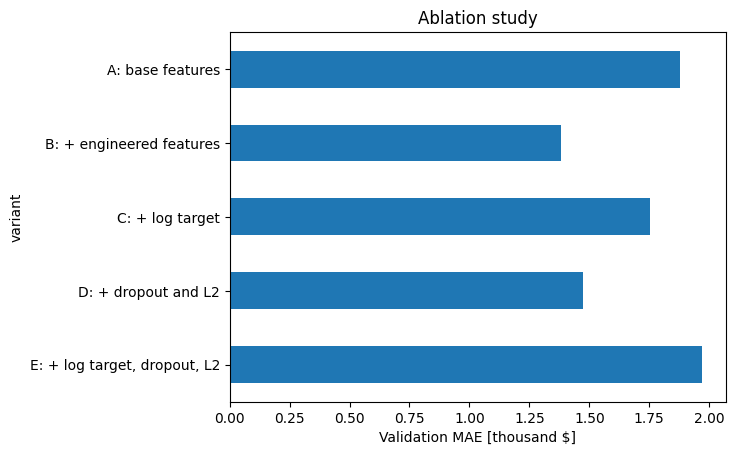

In [48]:
ext_ablation_df["val MAE [thousand $]"].plot(kind="barh")
plt.xlabel("Validation MAE [thousand $]")
plt.title("Ablation study")
plt.gca().invert_yaxis()

### 9.4 Hyperparameter tuning (random search)

Random search tries random combinations of settings. The search space includes the feature set, the target transform, the network size, regularisation, learning rate, batch size and loss. The best ablation variant is added as the first candidate, so the search cannot do worse than it. Trials are ranked by validation MAE.

In [49]:
ext_space = {
    "feats": ["base", "eng"],
    "log_target": [False, True],
    "units": [(32, 32), (64, 64), (128, 64), (128, 128, 64)],
    "dropout": [0.0, 0.1, 0.2],
    "l2": [0.0, 1e-4, 1e-3],
    "lr": [1e-3, 3e-3, 1e-2],
    "batch_size": [16, 32, 64],
    "loss": ["mean_absolute_error", "huber"],
}

ext_rng = np.random.default_rng(EXT_SEED)
ext_best_ablation = ext_ablation_df["val MAE [thousand $]"].idxmin()
ext_candidates = [ext_full_cfg(ext_ablation[ext_best_ablation])]
for _ in range(EXT_N_TRIALS):
    ext_candidates.append({k: v[ext_rng.integers(len(v))] for k, v in ext_space.items()})

ext_trials = []
for i, cfg in enumerate(ext_candidates):
    val_mae, n_ep = ext_run_config(cfg)
    ext_trials.append({**cfg, "val_mae": val_mae, "epochs": n_ep})
    print(f"trial {i:2d}: val MAE = {val_mae:.3f}  ({n_ep} epochs)")

ext_trials_df = pd.DataFrame(ext_trials).sort_values("val_mae").reset_index(drop=True)
ext_trials_df.head(5)

trial  0: val MAE = 1.383  (133 epochs)
trial  1: val MAE = 2.983  (65 epochs)
trial  2: val MAE = 2.196  (76 epochs)
trial  3: val MAE = 1.549  (91 epochs)
trial  4: val MAE = 2.247  (79 epochs)
trial  5: val MAE = 2.749  (65 epochs)
trial  6: val MAE = 2.837  (46 epochs)
trial  7: val MAE = 1.491  (169 epochs)
trial  8: val MAE = 1.544  (105 epochs)
trial  9: val MAE = 1.879  (115 epochs)
trial 10: val MAE = 2.158  (115 epochs)
trial 11: val MAE = 1.639  (65 epochs)
trial 12: val MAE = 2.016  (126 epochs)


,feats,log_target,units,dropout,l2,lr,batch_size,loss,val_mae,epochs
0,eng,False,"(64, 64)",0.0,0.0000,0.001,32,mean_absolute_error,1.382826,133
1,eng,True,"(128, 128, 64)",0.0,0.0001,0.003,32,mean_absolute_error,1.490789,169
2,eng,False,"(128, 64)",0.2,0.0010,0.010,32,huber,1.544232,105
3,eng,False,"(128, 128, 64)",0.1,0.0001,0.003,16,huber,1.548526,91
4,eng,False,"(32, 32)",0.2,0.0001,0.010,16,mean_absolute_error,1.639146,65


In [50]:
ext_best_trial = ext_trials[int(np.argmin([t["val_mae"] for t in ext_trials]))]
ext_best_cfg = {k: ext_best_trial[k] for k in ext_defaults}
print("Best configuration:")
for k, v in ext_best_cfg.items():
    print(f"  {k}: {v}")
print(f"Validation MAE: {ext_best_trial['val_mae']:.3f}")

Best configuration:
  feats: eng
  log_target: False
  units: (64, 64)
  dropout: 0.0
  l2: 0.0
  lr: 0.001
  batch_size: 32
  loss: mean_absolute_error
Validation MAE: 1.383


### 9.5 Final tuned DNN

The best configuration is trained on the full training set. The test set is used here for the first time.

In [51]:
ext_tuned_X_train = ext_select(ext_X_train, ext_best_cfg["feats"])
ext_tuned_X_test = ext_select(ext_X_test, ext_best_cfg["feats"])
ext_tuned_log = ext_best_cfg["log_target"]

ext_tuned_model, ext_tuned_hist = ext_fit(
    ext_tuned_X_train, ext_y_train,
    log_target=ext_tuned_log, batch_size=ext_best_cfg["batch_size"],
    units=ext_best_cfg["units"], dropout=ext_best_cfg["dropout"],
    l2=ext_best_cfg["l2"], lr=ext_best_cfg["lr"], loss=ext_best_cfg["loss"],
)
ext_tuned_model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_20                │ (None, 13)             │            27 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,392 (60.13 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 27 (112.00 B)

 Optimizer params: 10,244 (40.02 KB)

Epochs run: 168


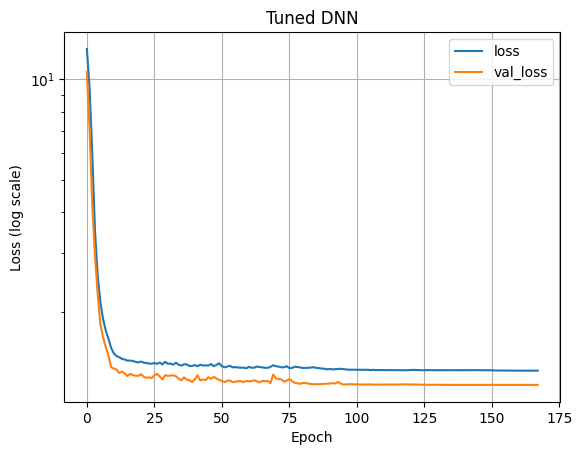

In [52]:
ext_plot_history(ext_tuned_hist, "Tuned DNN")
print("Epochs run:", len(ext_tuned_hist.history["loss"]))

In [53]:
ext_test_results = {}
ext_test_preds = {}

ext_test_preds["dnn_tuned"] = ext_predict(ext_tuned_model, ext_tuned_X_test, ext_tuned_log)
ext_test_results["dnn_tuned"] = ext_metrics(ext_y_test, ext_test_preds["dnn_tuned"])
ext_test_results["dnn_tuned"]

{'MAE [thousand $]': 1.3260899782180786,
 'RMSE [thousand $]': np.float64(4.4352467148548635),
 'R2': 0.861752986907959}

### 9.6 Gradient boosting baseline

Gradient boosting is a strong classic method for tabular data. It does not need normalised features. It shows whether a neural network is the right tool here.

In [54]:
ext_gb = GradientBoostingRegressor(random_state=EXT_SEED)
ext_gb.fit(X_train, ext_y_train)

ext_test_preds["gradient_boosting"] = ext_gb.predict(X_test)
ext_test_results["gradient_boosting"] = ext_metrics(ext_y_test, ext_test_preds["gradient_boosting"])
ext_test_results["gradient_boosting"]

{'MAE [thousand $]': 2.5373934257911226,
 'RMSE [thousand $]': np.float64(4.519383768119088),
 'R2': 0.8564581434279431}

### 9.7 K-fold cross-validation

One train/test split can be lucky or unlucky. Cross-validation repeats the evaluation on several splits of the training data. It reports the mean and the spread of the MAE. Normalisation is fitted inside each fold, so there is no leakage.

In [55]:
def ext_cv_score(fit_predict, X_all, y_all, n_splits=EXT_N_FOLDS):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=EXT_SEED)
    maes = []
    for tr, va in kf.split(X_all):
        pred = fit_predict(X_all[tr], y_all[tr], X_all[va])
        maes.append(mean_absolute_error(y_all[va], pred))
    return np.mean(maes), np.std(maes)


def ext_cv_dnn(cfg):
    cfg = ext_full_cfg(cfg)
    X_all = ext_select(ext_X_train, cfg["feats"])

    def fit_predict(Xa, ya, Xb):
        model, _ = ext_fit(
            Xa, ya, log_target=cfg["log_target"], batch_size=cfg["batch_size"],
            units=cfg["units"], dropout=cfg["dropout"], l2=cfg["l2"],
            lr=cfg["lr"], loss=cfg["loss"],
        )
        return ext_predict(model, Xb, cfg["log_target"])

    return ext_cv_score(fit_predict, X_all, ext_y_train)


def ext_cv_gb():
    def fit_predict(Xa, ya, Xb):
        m = GradientBoostingRegressor(random_state=EXT_SEED)
        m.fit(Xa, ya)
        return m.predict(Xb)

    return ext_cv_score(fit_predict, X_train, ext_y_train)

In [56]:
ext_cv_results = {
    "linear_multi_feature": ext_cv_dnn(dict(feats="base", units=(), lr=0.1)),
    "dnn_multi_feature": ext_cv_dnn(dict(feats="base")),
    "dnn_tuned": ext_cv_dnn(ext_best_cfg),
    "gradient_boosting": ext_cv_gb(),
}

ext_cv_df = pd.DataFrame(ext_cv_results, index=["CV MAE mean [thousand $]", "CV MAE std"]).T
ext_cv_df = ext_cv_df.sort_values("CV MAE mean [thousand $]")
ext_cv_df

,CV MAE mean [thousand $],CV MAE std
dnn_tuned,1.348024,0.265463
dnn_multi_feature,1.715607,0.342433
gradient_boosting,2.598835,0.145298
linear_multi_feature,3.767645,0.250370


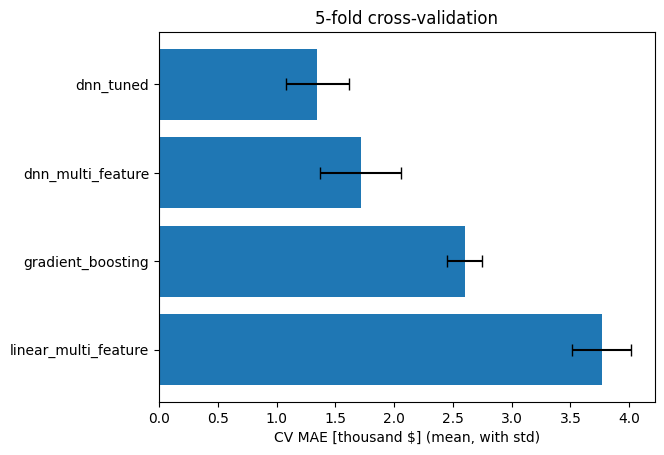

In [57]:
plt.barh(ext_cv_df.index, ext_cv_df["CV MAE mean [thousand $]"], xerr=ext_cv_df["CV MAE std"], capsize=4)
plt.xlabel("CV MAE [thousand $] (mean, with std)")
plt.title(f"{EXT_N_FOLDS}-fold cross-validation")
plt.gca().invert_yaxis()

### 9.8 Feature importance and error analysis

**Permutation importance** shuffles one feature at a time on the test set. The bigger the rise in MAE, the more the model relies on that feature.

In [58]:
def ext_permutation_importance(predict_fn, X, y, names, repeats=10, seed=EXT_SEED):
    rng = np.random.default_rng(seed)
    base = mean_absolute_error(y, predict_fn(X))
    rows = []
    for j, name in enumerate(names):
        deltas = []
        for _ in range(repeats):
            Xp = X.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            deltas.append(mean_absolute_error(y, predict_fn(Xp)) - base)
        rows.append((name, np.mean(deltas), np.std(deltas)))
    out = pd.DataFrame(rows, columns=["feature", "MAE increase [thousand $]", "std"])
    return out.sort_values("MAE increase [thousand $]", ascending=False).reset_index(drop=True)


ext_names_used = feature_names if ext_best_cfg["feats"] == "base" else ext_feature_names
ext_importance = ext_permutation_importance(
    lambda X: ext_predict(ext_tuned_model, X, ext_tuned_log),
    ext_tuned_X_test, ext_y_test, ext_names_used,
)
ext_importance

,feature,MAE increase [thousand $],std
0,smoker_yes,2.219839,0.155292
1,smoker_x_bmi,2.204949,0.133614
2,age_sq,2.182551,0.073894
3,smoker_x_obese,1.971384,0.143790
4,age,1.406812,0.062667
5,smoker_x_age,0.782539,0.023619
6,children,0.645410,0.034531
7,bmi,0.554951,0.043354
8,bmi_sq,0.433935,0.017863
9,region_southeast,0.201591,0.014091


Text(0.5, 1.0, 'Permutation importance (tuned DNN)')

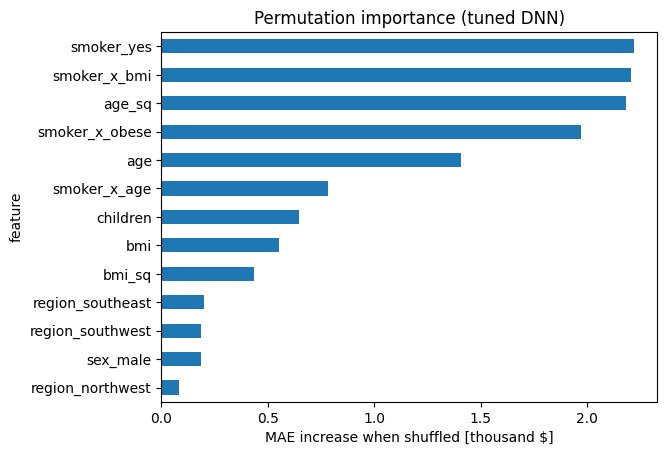

In [59]:
ext_importance.sort_values("MAE increase [thousand $]").plot(
    kind="barh", x="feature", y="MAE increase [thousand $]", legend=False
)
plt.xlabel("MAE increase when shuffled [thousand $]")
plt.title("Permutation importance (tuned DNN)")

**Error by group.** This shows where the tuned DNN makes its largest errors.

In [60]:
ext_abs_err = np.abs(ext_y_test - ext_test_preds["dnn_tuned"])
ext_group = pd.DataFrame({
    "smoker": np.where(test_features[EXT_SMOKER].to_numpy() == 1, "smoker", "non-smoker"),
    "abs_error": ext_abs_err,
})
ext_group.groupby("smoker")["abs_error"].agg(["count", "mean", "median", "max"])

,count,mean,median,max
smoker,,,,
non-smoker,213,1.185341,0.027514,22.576866
smoker,54,1.881269,0.127089,18.414825


### 9.9 Final comparison

All models are scored on the same test set. Errors are in thousand dollars.

In [61]:
for ext_name, (ext_m, ext_X) in registry.items():
    ext_test_preds[ext_name] = ext_m.predict(ext_X, verbose=0).flatten()

ext_all_results = pd.concat([results_df, pd.DataFrame(ext_test_results).T])
ext_all_results = ext_all_results.sort_values("MAE [thousand $]")
ext_all_results

,MAE [thousand $],RMSE [thousand $],R2
dnn_tuned,1.326090,4.435247,0.861753
dnn_multi_feature,1.570323,4.529794,0.855796
gradient_boosting,2.537393,4.519384,0.856458
linear_multi_feature,3.341831,6.947544,0.660779
dnn_one_feature,6.413130,12.858421,-0.161971
linear_one_feature,6.441299,12.764525,-0.145063


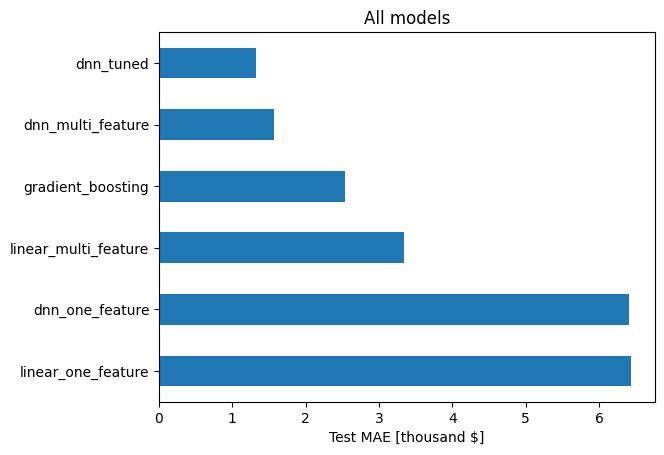

In [62]:
ext_all_results["MAE [thousand $]"].plot(kind="barh")
plt.xlabel("Test MAE [thousand $]")
plt.title("All models")
plt.gca().invert_yaxis()

Best model overall: dnn_tuned


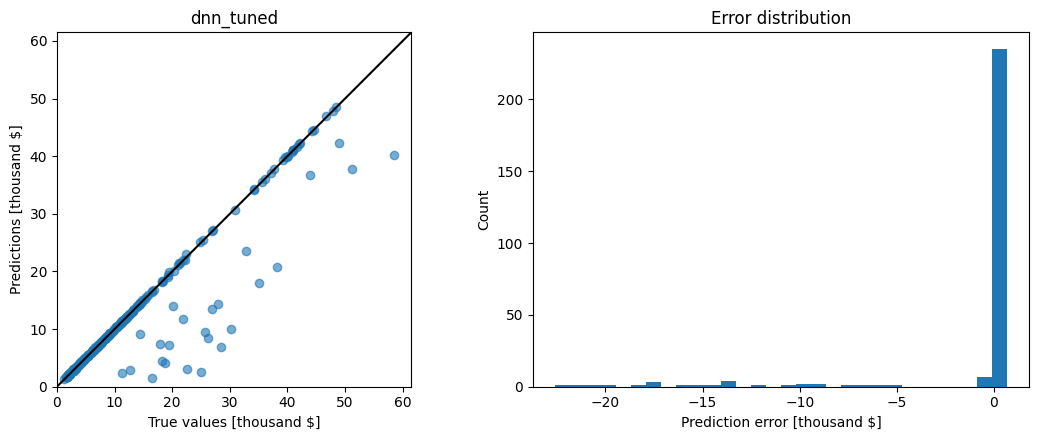

In [63]:
def ext_plot_predictions(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].scatter(y_true, y_pred, alpha=0.6)
    top = max(y_true.max(), y_pred.max()) * 1.05
    axes[0].plot([0, top], [0, top], color="k")
    axes[0].set_xlim(0, top)
    axes[0].set_ylim(0, top)
    axes[0].set_aspect("equal")
    axes[0].set_xlabel("True values [thousand $]")
    axes[0].set_ylabel("Predictions [thousand $]")
    axes[0].set_title(title)

    axes[1].hist(y_pred - y_true, bins=30)
    axes[1].set_xlabel("Prediction error [thousand $]")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Error distribution")
    plt.tight_layout()


ext_best_overall = ext_all_results.index[0]
print("Best model overall:", ext_best_overall)
ext_plot_predictions(ext_y_test, ext_test_preds[ext_best_overall], ext_best_overall)

## 10. Conclusion

**Best model.** The tuned DNN with engineered features performed best on the test set: MAE 1.33 (about $1,330), RMSE 4.44 and R² 0.862.

**Effect of extra features.** Moving from one feature to all features cut the MAE by about 48% for the linear model and about 76% for the DNN. Age alone is a weak predictor. Both one-feature models have negative R², so they do worse than predicting the average charge.

**DNN vs linear.** With all features, the DNN cut the MAE by about 53% compared with the linear model. The DNN can learn non-linear patterns and interactions. The linear model cannot. With one feature, the DNN and the linear model scored almost the same. One feature gives the DNN little to work with.

**Extension: what helped.** The ablation study used validation MAE.
- Engineered features helped the most. They cut the MAE from 1.88 to 1.38 (about 26%).
- The log-transformed target made it worse (1.75). The log scale treats all errors as relative, but MAE in dollars is driven by the large charges.
- Dropout and L2 made it slightly worse (1.47). Early stopping already controls overfitting here.
- Log target with dropout and L2 together was the worst (1.97).

**Extension: tuning.** Random search tried 12 more configurations. None beat the engineered-feature DNN with default settings (two layers of 64 units, MAE loss, learning rate 0.001). The final tuned model is that configuration trained on the full training set. Tuning did not add more.

**Extension: cross-validation.** The 5-fold results give the same ranking as the test set.

The gap between the tuned DNN and the plain DNN (0.37) is close to the fold-to-fold spread. The gain from engineered features is likely, but not certain.

**Extension: gradient boosting.** Gradient boosting reached nearly the same R² as the DNN (0.856), but its MAE was about 48% higher. The DNN with engineered features is the better choice here.

**Extension: feature importance.** Smoker status matters most. The smoker-related features (`smoker_yes`, `smoker_x_bmi`, `smoker_x_obese`) and `age_sq` raised the MAE by about 2 when shuffled. Age came next, then `smoker_x_age`, children and BMI. Region and sex matter least. These features overlap, so their scores should be read as a group.

**Overfitting.** There was no sign of overfitting. Training and validation loss of the tuned model stayed close together, and early stopping ended training at 168 epochs.

**Error analysis.** Most predictions are very close to the true value. The median absolute error is about $30 for non-smokers and about $130 for smokers. A small group of cases (about 25 of 267) are under-predicted by a large amount, up to about $22,600. These cases explain why the RMSE (4.44) is much higher than the MAE (1.33). The mean error is higher for smokers (1.88) than for non-smokers (1.19).

**Limitations.**
- Only 1,337 unique rows remain after removing duplicates.
- The test set has 267 rows, so a few large misses change the scores.
- The model under-predicts some high-cost cases.

**Possible improvements.** Add more features or interactions, search more configurations, try a loss that focuses on large charges, or combine several models.